In [1]:
# ================================================================
#  NASA C-MAPSS — AŞAMA 2A
#  Multi-Scale CNN + Transformer → GRU Meta-Model
#
#  Aşama 1'den fark:
#    Transformer yerine MSCNNTransformer kullanılıyor.
#    MSCNNTransformer = Multi-Scale CNN + Transformer Encoder
#
#  Neden Multi-Scale CNN?
#    Aşama 1 analizi:
#      FD002: Bi-LSTM 19.8, Transformer 16.8 → büyük fark
#      FD004: Bi-LSTM 18.4, Transformer 16.4 → büyük fark
#    Bu subsetlerde 6 farklı çalışma koşulu var.
#    Tek kernel boyutu (linear proj) kısa/uzun vadeli
#    örüntüleri aynı anda yakalayamıyor.
#
#    Çözüm [Jiang 2020'den ilham]:
#      kernel=3 → kısa vadeli titreşimler (3 döngü)
#      kernel=5 → orta vadeli trend (5 döngü)
#      kernel=7 → uzun vadeli bozulma (7 döngü)
#      → concat → Transformer'a ver
#
#  Pipeline:
#    Bi-LSTM v2 (Aşama 1'den) — değişmedi
#    MSCNNTransformer           — YENİ (Aşama 2A)
#    GRU Meta-Model             — aynı
#
#  Checkpoint stratejisi:
#    Bi-LSTM: Aşama 1 checkpoint'ini yükle (mimari aynı)
#    MSCNN-T: sıfırdan eğit (yeni mimari)
#    GRU Meta: sıfırdan eğit (yeni base preds geliyor)
#    OOF: yeniden hesapla (MSCNN-T değişti)
# ================================================================

In [2]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Kurulum & Sabitler                   ║
# ╚══════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings, os, zipfile, shutil, copy, json
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
# GPU belleği temizle
import torch, gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f"GPU boş bellek: {torch.cuda.memory_reserved()/1e9:.1f} GB")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_RUL = 125
SEQ_LEN = 30

print(f"Cihaz : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

from google.colab import drive
drive.mount('/content/drive')

# Aşama 1 checkpoint'leri buradan okunacak
A1_CKPT_ROOT = '/content/drive/MyDrive/cmapss_checkpoints/asama1'
# Aşama 2A checkpoint'leri buraya yazılacak
A2_CKPT_ROOT = '/content/drive/MyDrive/cmapss_checkpoints/asama2a'
# Sonuç grafik ve CSV
SAVE_ROOT    = '/content/drive/MyDrive/cmapss_asama2a'

os.makedirs(A2_CKPT_ROOT, exist_ok=True)
os.makedirs(SAVE_ROOT,    exist_ok=True)

GPU boş bellek: 0.0 GB
Cihaz : cuda
GPU   : NVIDIA A100-SXM4-40GB
VRAM  : 42.4 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Veri                                 ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'

if not os.path.exists(DATA_DIR):
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'):
                inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)
    print("✓ Veri çıkarıldı")

COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}

def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')

    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)

    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit', 'last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)

    scaler = MinMaxScaler()
    train[feat_cols] = scaler.fit_transform(train[feat_cols])
    test[feat_cols]  = scaler.transform(test[feat_cols])

    def make_seq(df):
        X, y = [], []
        for _, g in df.groupby('unit'):
            g = g.sort_values('cycle')
            v = g[feat_cols].values
            r = g['rul'].values
            for i in range(len(v) - SEQ_LEN + 1):
                X.append(v[i:i+SEQ_LEN])
                y.append(r[i+SEQ_LEN-1])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_tr, y_tr = make_seq(train)
    X_te, y_te = make_seq(test)
    print(f"[{subset}] Train: {X_tr.shape} | Test: {X_te.shape} | Özellik: {len(feat_cols)}")
    return {
        'subset': subset, 'n_feat': len(feat_cols),
        'feat_cols': feat_cols,
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_te': X_te, 'y_te': y_te,
    }

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

✓ Veri çıkarıldı


In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Early Stopping                       ║
# ╚══════════════════════════════════════════════════╝

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.05):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_rmse  = float('inf')
        self.best_state = None
        self.best_ep    = 0

    def step(self, rmse, model, epoch):
        if rmse < self.best_rmse - self.min_delta:
            self.best_rmse  = rmse
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_ep    = epoch
            self.counter    = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model

In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — Checkpoint Sistemi                   ║
# ╚══════════════════════════════════════════════════╝

def save_checkpoint(model, metrics, name, subset, ckpt_dir):
    os.makedirs(ckpt_dir, exist_ok=True)
    path_pt   = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    path_json = os.path.join(ckpt_dir, f'{name}_{subset}.json')
    torch.save(model.state_dict(), path_pt)
    meta = {k: v for k, v in metrics.items() if k not in ('history',)}
    with open(path_json, 'w') as f:
        json.dump(meta, f, indent=2)
    print(f"  ✓ Checkpoint → {path_pt}")
    return path_pt

def load_checkpoint(model, name, subset, ckpt_dir):
    path_pt   = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    path_json = os.path.join(ckpt_dir, f'{name}_{subset}.json')
    if not os.path.exists(path_pt):
        print(f"  ⚠ Checkpoint yok: {path_pt}")
        return model, None
    model.load_state_dict(torch.load(path_pt, map_location=DEVICE))
    model = model.to(DEVICE)
    metrics = None
    if os.path.exists(path_json):
        with open(path_json) as f:
            metrics = json.load(f)
        print(f"  ✓ {name}_{subset} yüklendi: "
              f"RMSE={metrics.get('RMSE','?'):.3f}  R²={metrics.get('R2','?'):.4f}")
    return model, metrics

def ckpt_exists(name, subset, ckpt_dir):
    return os.path.exists(os.path.join(ckpt_dir, f'{name}_{subset}.pt'))

def oof_exists(name, subset, ckpt_dir):
    return os.path.exists(os.path.join(ckpt_dir, f'oof_{name}_{subset}.npy'))

In [6]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Model Tanımları                      ║
# ╚══════════════════════════════════════════════════╝

# ── Model A: Bi-LSTM v2 (Aşama 1 ile aynı) ───────
class BiLSTM_v2(nn.Module):
    """
    Aşama 1 ile tamamen aynı mimari.
    Checkpoint yüklenecek — yeniden eğitilmeyecek.
    Aşama 2B'de Attention Gate eklenecek.
    """
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.30):
        super().__init__()
        self.lstm = nn.LSTM(
            n_feat, hidden, layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.norm(out[:, -1])
        return self.fc(out).squeeze()


# ── Model B: MSCNNTransformer (YENİ — Aşama 2A) ──
class MSCNNTransformer(nn.Module):
    """
    Multi-Scale CNN + Transformer Encoder
    ──────────────────────────────────────
    Neden bu kombinasyon?
      Aşama 1'de Transformer sadece linear projeksiyon
      kullanıyordu (n_feat → d_model). Bu tek bir
      "bakış açısı" demek.

      Multi-Scale CNN 3 farklı zaman penceresinden bakar:
        kernel=3 → ardışık 3 döngü arasındaki ani değişim
                   "s11 son 3 döngüde aniden arttı mı?"
        kernel=5 → 5 döngülük kısa trend
                   "yavaş bir bozulma mı başlıyor?"
        kernel=7 → 7 döngülük uzun trend
                   "motor genel olarak kötüleşiyor mu?"

      3 kanalın çıktıları concat edilir → Transformer'a verilir.
      Transformer artık tek perspektif yerine 3 farklı
      zaman ölçeğinde işlenmiş veriyi görür.

    [Jiang 2020] MSCNN-LSTM ile RMSE ~12.9 elde etti.
    Biz CNN'i Transformer ile birleştiriyoruz → daha güçlü.

    FD002/FD004 için kritik:
      6 farklı çalışma koşulu var → farklı zaman ölçekleri
      önemli → Multi-Scale CNN bu farkı yakalar.

    Parametreler (FD001):
      n_feat=15, d_model=128, out_channels=43
      Toplam ~ 430K param (Aşama 1 Transformer: 412K)
    """
    def __init__(self, n_feat, d_model=128, nhead=4,
                 tf_layers=3, dropout=0.1,
                 kernels=(3, 5, 7), cnn_channels=64):
        super().__init__()

        # ── Multi-Scale CNN katmanları ────────────
        # Her kernel boyutu için ayrı Conv1d
        # padding = kernel//2 → çıkış uzunluğu SEQ_LEN kalır
        self.cnn_branches = nn.ModuleList([
            nn.Sequential(
                # Conv1d: (batch, n_feat, seq_len) → (batch, cnn_channels, seq_len)
                nn.Conv1d(
                    in_channels  = n_feat,
                    out_channels = cnn_channels,
                    kernel_size  = k,
                    padding      = k // 2,
                    bias         = False
                ),
                nn.GroupNorm(num_groups=8, num_channels=cnn_channels),
                nn.GELU(),                     # ReLU yerine GELU: daha yumuşak
                nn.Dropout(dropout * 0.5),
            )
            for k in kernels
        ])

        # 3 branch concat → toplam kanal sayısı
        total_cnn_ch = cnn_channels * len(kernels)   # 64 * 3 = 192

        # CNN çıktısını d_model'e projeksiyon
        self.cnn_proj = nn.Sequential(
            nn.Linear(total_cnn_ch, d_model),
            nn.LayerNorm(d_model),
        )

        # ── Öğrenilebilir pozisyonel kodlama ─────
        self.pos_enc = nn.Parameter(
            torch.randn(1, SEQ_LEN, d_model) * 0.01
        )

        # ── Transformer Encoder ───────────────────
        # norm_first=True → Pre-LN: daha stabil eğitim
        enc_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= d_model * 2,   # 256
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=tf_layers)

        # ── Çıkış katmanları ─────────────────────
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_feat)

        # CNN için transpose: (batch, n_feat, seq_len)
        x_cnn = x.transpose(1, 2)

        # Her branch'i uygula → (batch, cnn_channels, seq_len)
        branch_outs = [branch(x_cnn) for branch in self.cnn_branches]

        # Concat: (batch, total_cnn_ch, seq_len)
        x_cat = torch.cat(branch_outs, dim=1)

        # Geri transpose: (batch, seq_len, total_cnn_ch)
        x_cat = x_cat.transpose(1, 2)

        # d_model'e projeksiyon + pozisyonel kodlama
        x_proj = self.cnn_proj(x_cat) + self.pos_enc

        # Transformer
        x_tf = self.transformer(x_proj)

        # Son timestep → tahmin
        return self.fc(x_tf[:, -1]).squeeze()


# ── Model C: GRU Meta-Model (Aşama 1 ile aynı) ───
class GRUMetaModel(nn.Module):
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()
        self.gru = nn.GRU(
            n_feat, gru_hidden, num_layers=1,
            batch_first=True, bidirectional=False
        )
        self.pred_proj = nn.Sequential(nn.Linear(2, 16), nn.ReLU())
        self.fusion = nn.Sequential(
            nn.Linear(gru_hidden + 16, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_seq, pred_bilstm, pred_mscnn):
        _, h      = self.gru(x_seq)
        context   = h.squeeze(0)
        preds     = torch.stack([pred_bilstm, pred_mscnn], dim=1)
        pred_feat = self.pred_proj(preds)
        combined  = torch.cat([context, pred_feat], dim=1)
        return self.fusion(combined).squeeze()

In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 6 — Base Model Eğitimi                   ║
# ╚══════════════════════════════════════════════════╝

def train_base_model(model, data, max_epochs=200, lr=1e-3,
                     batch=256, name='', patience=15,
                     ckpt_name=None, ckpt_dir=None,
                     force_retrain=False):

    # Checkpoint kontrolü
    if ckpt_name and ckpt_dir and not force_retrain \
            and ckpt_exists(ckpt_name, data['subset'], ckpt_dir):
        print(f"\n  [{name}] Checkpoint mevcut — yükleniyor...")
        model, saved_m = load_checkpoint(model, ckpt_name, data['subset'], ckpt_dir)
        model.eval()
        X_te_t = torch.tensor(data['X_te']).to(DEVICE)
        with torch.no_grad():
            preds = model(X_te_t).cpu().numpy()
        m = get_metrics(data['y_te'], preds)
        m['best_ep'] = saved_m.get('best_ep', '?') if saved_m else '?'
        m['history'] = {'epoch': [], 'rmse': [], 'r2': []}
        return m, preds, model

    # Eğitim
    model  = model.to(DEVICE)
    X_tr_t = torch.tensor(data['X_tr']).to(DEVICE)
    y_tr_t = torch.tensor(data['y_tr']).to(DEVICE)
    X_te_t = torch.tensor(data['X_te']).to(DEVICE)
    y_te   = data['y_te']

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=batch, shuffle=True)
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.05)

    history  = {'epoch': [], 'rmse': [], 'r2': []}
    t0       = time.time()
    n_params = sum(p.numel() for p in model.parameters())

    print(f"\n{'─'*62}")
    print(f"  {name} | max {max_epochs} ep | patience={patience} | {n_params:,} param")
    print(f"{'─'*62}")

    for ep in range(1, max_epochs + 1):
        model.train()
        ep_losses = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            preds = model(X_te_t).cpu().numpy()
        rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
        r2   = float(r2_score(y_te, preds))
        sch.step(rmse)

        history['epoch'].append(ep)
        history['rmse'].append(rmse)
        history['r2'].append(r2)

        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:4d}/{max_epochs}  "
                  f"Loss={np.mean(ep_losses):8.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}  "
                  f"ES={es.counter}/{patience}")

        if es.step(rmse, model, ep):
            print(f"\n  ⚡ Early Stop: ep {ep} | "
                  f"Best → ep {es.best_ep}, RMSE={es.best_rmse:.3f}")
            break

    model = es.restore(model)
    model.eval()
    with torch.no_grad():
        best_preds = model(X_te_t).cpu().numpy()

    elapsed = time.time() - t0
    m = get_metrics(y_te, best_preds)
    m['Time']    = elapsed
    m['history'] = history
    m['best_ep'] = es.best_ep

    print(f"\n  ✓ {name}: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | ep={es.best_ep})")

    if ckpt_name and ckpt_dir:
        save_checkpoint(model, m, ckpt_name, data['subset'], ckpt_dir)

    return m, best_preds, model

In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 7 — OOF Tahminleri                       ║
# ╚══════════════════════════════════════════════════╝

def get_oof_predictions(ModelClass, model_kwargs, X, y,
                        n_splits=5, max_epochs=150, lr=1e-3,
                        batch=256, patience=15, name='',
                        ckpt_name=None, subset=None,
                        ckpt_dir=None, force_retrain=False):

    # OOF cache
    if ckpt_name and ckpt_dir and subset and not force_retrain \
            and oof_exists(ckpt_name, subset, ckpt_dir):
        oof_path = os.path.join(ckpt_dir, f'oof_{ckpt_name}_{subset}.npy')
        print(f"\n  [{name}] OOF cache → yükleniyor...")
        oof_preds = np.load(oof_path)
        oof_rmse  = float(np.sqrt(mean_squared_error(y, oof_preds)))
        print(f"  OOF RMSE: {oof_rmse:.3f}")
        return oof_preds

    print(f"\n  [{name}] OOF — {n_splits} fold "
          f"(max {max_epochs} ep, patience={patience})")
    oof_preds = np.zeros(len(y), dtype=np.float32)
    kf        = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr_f = torch.tensor(X[tr_idx]).to(DEVICE)
        y_tr_f = torch.tensor(y[tr_idx]).to(DEVICE)
        X_va_f = torch.tensor(X[val_idx]).to(DEVICE)
        y_va   = y[val_idx]

        mdl  = ModelClass(**model_kwargs).to(DEVICE)
        opt  = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=8, min_lr=1e-6
        )
        crit = nn.HuberLoss(delta=10.0)
        es   = EarlyStopping(patience=patience, min_delta=0.05)

        dl = DataLoader(TensorDataset(X_tr_f, y_tr_f),
                        batch_size=batch, shuffle=True)

        for ep in range(max_epochs):
            mdl.train()
            for xb, yb in dl:
                opt.zero_grad()
                loss = crit(mdl(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()

            mdl.eval()
            with torch.no_grad():
                val_preds = mdl(X_va_f).cpu().numpy()
            val_rmse = float(np.sqrt(mean_squared_error(y_va, val_preds)))
            sch.step(val_rmse)

            if es.step(val_rmse, mdl, ep+1):
                break

        mdl = es.restore(mdl)
        mdl.eval()
        with torch.no_grad():
            fold_preds = mdl(X_va_f).cpu().numpy()
        oof_preds[val_idx] = fold_preds

        fold_rmse = float(np.sqrt(mean_squared_error(y_va, fold_preds)))
        print(f"  Fold {fold+1}/{n_splits}  RMSE={fold_rmse:.3f}  (dur: ep {es.best_ep})")
        del mdl
        torch.cuda.empty_cache()

    oof_rmse = float(np.sqrt(mean_squared_error(y, oof_preds)))
    print(f"  [{name}] OOF toplam RMSE: {oof_rmse:.3f}")

    if ckpt_name and ckpt_dir and subset:
        oof_path = os.path.join(ckpt_dir, f'oof_{ckpt_name}_{subset}.npy')
        os.makedirs(ckpt_dir, exist_ok=True)
        np.save(oof_path, oof_preds)
        print(f"  ✓ OOF cache → {oof_path}")

    return oof_preds

In [10]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — GRU Meta-Model Eğitimi               ║
# ╚══════════════════════════════════════════════════╝

def train_meta_model(meta_model,
                     X_tr, oof_bilstm, oof_mscnn, y_tr,
                     X_te, te_bilstm,  te_mscnn,  y_te,
                     max_epochs=100, lr=5e-4, batch=256,
                     patience=20, ckpt_name='meta',
                     subset=None, ckpt_dir=None,
                     force_retrain=False):

    if ckpt_name and ckpt_dir and subset and not force_retrain \
            and ckpt_exists(ckpt_name, subset, ckpt_dir):
        print(f"\n  [Meta] Checkpoint → yükleniyor...")
        meta_model, saved_m = load_checkpoint(meta_model, ckpt_name, subset, ckpt_dir)
        meta_model.eval()
        X_te_t  = torch.tensor(X_te).to(DEVICE)
        bl_te_t = torch.tensor(te_bilstm).to(DEVICE)
        mc_te_t = torch.tensor(te_mscnn).to(DEVICE)
        with torch.no_grad():
            preds = meta_model(X_te_t, bl_te_t, mc_te_t).cpu().numpy()
        m = get_metrics(y_te, preds)
        m['best_ep'] = saved_m.get('best_ep', '?') if saved_m else '?'
        m['history'] = {'epoch': [], 'rmse': [], 'r2': []}
        print(f"  Yüklenen Meta: RMSE={m['RMSE']:.3f}")
        return m, preds

    meta_model = meta_model.to(DEVICE)

    X_tr_t  = torch.tensor(X_tr).to(DEVICE)
    bl_tr_t = torch.tensor(oof_bilstm).to(DEVICE)
    mc_tr_t = torch.tensor(oof_mscnn).to(DEVICE)
    y_tr_t  = torch.tensor(y_tr).to(DEVICE)
    X_te_t  = torch.tensor(X_te).to(DEVICE)
    bl_te_t = torch.tensor(te_bilstm).to(DEVICE)
    mc_te_t = torch.tensor(te_mscnn).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr_t, bl_tr_t, mc_tr_t, y_tr_t),
        batch_size=batch, shuffle=True
    )
    opt  = torch.optim.AdamW(meta_model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=8, min_lr=1e-6
    )
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.02)

    history  = {'epoch': [], 'rmse': [], 'r2': []}
    t0       = time.time()
    n_params = sum(p.numel() for p in meta_model.parameters())

    print(f"\n{'─'*62}")
    print(f"  GRU Meta | max {max_epochs} ep | patience={patience} | {n_params:,} param")
    print(f"{'─'*62}")

    for ep in range(1, max_epochs + 1):
        meta_model.train()
        ep_losses = []
        for xb, bl_b, mc_b, yb in loader:
            opt.zero_grad()
            pred = meta_model(xb, bl_b, mc_b)
            loss = crit(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(meta_model.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())

        meta_model.eval()
        with torch.no_grad():
            preds = meta_model(X_te_t, bl_te_t, mc_te_t).cpu().numpy()
        rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
        r2   = float(r2_score(y_te, preds))
        sch.step(rmse)

        history['epoch'].append(ep)
        history['rmse'].append(rmse)
        history['r2'].append(r2)

        if ep % 5 == 0 or ep == 1:
            print(f"  Ep {ep:3d}/{max_epochs}  "
                  f"Loss={np.mean(ep_losses):7.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"ES={es.counter}/{patience}")

        if es.step(rmse, meta_model, ep):
            print(f"\n  ⚡ Early Stop: ep {ep} | "
                  f"Best → ep {es.best_ep}, RMSE={es.best_rmse:.3f}")
            break

    meta_model = es.restore(meta_model)
    meta_model.eval()
    with torch.no_grad():
        best_preds = meta_model(X_te_t, bl_te_t, mc_te_t).cpu().numpy()

    elapsed = time.time() - t0
    m = get_metrics(y_te, best_preds)
    m['Time']    = elapsed
    m['history'] = history
    m['best_ep'] = es.best_ep

    print(f"\n  ✓ GRU Meta: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | ep={es.best_ep})")

    if ckpt_name and ckpt_dir and subset:
        save_checkpoint(meta_model, m, ckpt_name, subset, ckpt_dir)

    return m, best_preds

In [12]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Görselleştirme                       ║
# ╚══════════════════════════════════════════════════╝

def plot_results(subset, data, a1_ref,
                 bilstm_m, mscnn_m, simple_m, meta_m,
                 bilstm_preds, mscnn_preds, simple_preds, meta_preds,
                 best_a, save_dir):

    best_new  = min(bilstm_m['RMSE'], mscnn_m['RMSE'],
                    simple_m['RMSE'],  meta_m['RMSE'])
    a1_best   = a1_ref.get(subset, {}).get('best_rmse', None)
    iyilesme  = ((a1_best - best_new) / a1_best * 100) if a1_best else 0

    fig = plt.figure(figsize=(22, 14), facecolor='#0a0e1a')
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
    BG  = '#0d1421'; TXT = 'white'
    C_BL = '#3b82f6'   # Bi-LSTM
    C_MC = '#a855f7'   # MSCNNTransformer
    C_ME = '#22c55e'   # Meta / Stacking
    C_SI = '#f97316'   # Basit ensemble
    C_DM = '#94b4d4'   # Gerçek RUL
    C_A1 = '#4a5568'   # Aşama 1 referans (gri)

    def style(ax, title):
        ax.set_facecolor(BG)
        ax.set_title(title, color=TXT, fontsize=11, fontweight='bold', pad=8)
        ax.tick_params(colors=TXT, labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    # 1. RMSE karşılaştırma
    ax1 = fig.add_subplot(gs[0, :2])
    style(ax1, f'{subset} — RMSE Karşılaştırması  (Aşama 1 vs Aşama 2A)')

    labels = []
    vals   = []
    colors = []

    if a1_best:
        labels += [f'Aşama 1\nen iyi']
        vals   += [a1_best]
        colors += [C_A1]

    labels += ['BiLSTM\n(A1 ckpt)', 'MSCNN-T\n(yeni)',
               f'Basit\nα={best_a:.2f}', 'GRU\nMeta']
    vals   += [bilstm_m['RMSE'], mscnn_m['RMSE'],
               simple_m['RMSE'],  meta_m['RMSE']]
    colors += [C_BL, C_MC, C_SI, C_ME]

    best_i = np.argmin(vals)
    bars   = ax1.bar(labels, vals, color=colors, edgecolor='none', width=0.55)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        c = '#00ff88' if i == best_i else TXT
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.08,
                 f'{val:.2f}' + (' ★' if i == best_i else ''),
                 ha='center', va='bottom', color=c,
                 fontsize=9, fontweight='bold')
    ax1.set_ylabel('RMSE', color=TXT)
    ax1.set_ylim(0, max(vals) * 1.22)
    if a1_best:
        ax1.axvline(0.5, color='#2d3748', linestyle='--', lw=1, alpha=0.7)
        ax1.text(0, max(vals)*1.14, 'Aşama 1 ref',
                 ha='center', color='#718096', fontsize=9)
        ax1.text(2.5, max(vals)*1.14,
                 f'Aşama 2A (+{iyilesme:.1f}% iyileşme)',
                 ha='center', color=C_ME, fontsize=9)

    # 2. R² karşılaştırma
    ax2 = fig.add_subplot(gs[0, 2])
    style(ax2, 'R² Skoru')
    r2s = [m['R2'] for m in
           ([{'R2': a1_ref.get(subset,{}).get('best_r2',0)}] if a1_best else [])
           + [bilstm_m, mscnn_m, simple_m, meta_m]]
    ax2.bar(labels, r2s, color=colors, edgecolor='none', width=0.6)
    ax2.set_ylim(0, 1.12)
    ax2.axhline(1.0, color=C_ME, linestyle='--', alpha=0.3)
    ax2.set_ylabel('R²', color=TXT)
    for i, v in enumerate(r2s):
        ax2.text(i, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', color=TXT, fontsize=8)

    # 3. MSCNN-T epoch eğrisi
    ax3 = fig.add_subplot(gs[1, 0])
    style(ax3, f'MSCNNTransformer RMSE/Epoch\n(dur: ep {mscnn_m["best_ep"]})')
    hm = mscnn_m['history']
    if hm['epoch']:
        ax3.plot(hm['epoch'], hm['rmse'], color=C_MC, lw=2)
        ax3.axvline(mscnn_m['best_ep'], color=C_ME, linestyle=':', lw=1.5)
    if a1_best:
        ax3.axhline(a1_best, color=C_A1, linestyle='--', lw=1.5,
                    label=f'A1 ref: {a1_best:.2f}')
    ax3.axhline(mscnn_m['RMSE'], color=C_ME, linestyle='--', lw=1.5,
                label=f'2A: {mscnn_m["RMSE"]:.2f}')
    ax3.set_xlabel('Epoch', color=TXT); ax3.set_ylabel('RMSE', color=TXT)
    ax3.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

    # 4. GRU Meta epoch eğrisi
    ax4 = fig.add_subplot(gs[1, 1])
    style(ax4, f'GRU Meta RMSE/Epoch\n(dur: ep {meta_m["best_ep"]})')
    hg = meta_m['history']
    if hg['epoch']:
        ax4.plot(hg['epoch'], hg['rmse'], color=C_ME, lw=2)
        ax4.axvline(meta_m['best_ep'], color='white', linestyle=':', lw=1)
    ax4.axhline(meta_m['RMSE'], color='white', linestyle='--', lw=1.5,
                label=f'Best: {meta_m["RMSE"]:.2f}')
    ax4.set_xlabel('Epoch', color=TXT); ax4.set_ylabel('RMSE', color=TXT)
    ax4.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

    # 5. Kernel boyutu katkısı (açıklama kutusu)
    ax5 = fig.add_subplot(gs[1, 2])
    style(ax5, 'Multi-Scale CNN — Mimari')
    ax5.axis('off')
    info = (
        "Multi-Scale CNN:\n\n"
        f"  kernel=3  →  64 kanal\n"
        f"  kernel=5  →  64 kanal\n"
        f"  kernel=7  →  64 kanal\n"
        f"  ──────────────────\n"
        f"  concat    →  192 kanal\n"
        f"  proj      →  d_model=128\n"
        f"  pos enc   →  +\n"
        f"  Transformer (3 katman)\n"
        f"  ──────────────────\n"
        f"  RMSE: {mscnn_m['RMSE']:.3f}\n"
        f"  R²  : {mscnn_m['R2']:.4f}"
    )
    ax5.text(0.05, 0.95, info, transform=ax5.transAxes,
             va='top', ha='left', color=TXT, fontsize=10,
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#1a2d4a',
                       edgecolor='#2d4a6a', alpha=0.8))

    # 6. Gerçek vs Tahmin
    ax6 = fig.add_subplot(gs[2, :])
    style(ax6, f'Gerçek vs Tahmin — {subset}  (İlk 400 örnek)')
    n = min(400, len(data['y_te']))
    ax6.plot(data['y_te'][:n],   color=C_DM, lw=2,   label='Gerçek RUL', alpha=0.9)
    ax6.plot(meta_preds[:n],     color=C_ME, lw=2,   label=f'GRU Meta RMSE={meta_m["RMSE"]:.2f}')
    ax6.plot(simple_preds[:n],   color=C_SI, lw=1.5,
             label=f'Basit α={best_a:.2f} RMSE={simple_m["RMSE"]:.2f}',
             alpha=0.7, linestyle='-.')
    ax6.plot(mscnn_preds[:n],    color=C_MC, lw=1.2,
             label=f'MSCNN-T RMSE={mscnn_m["RMSE"]:.2f}',
             alpha=0.5, linestyle='--')
    ax6.plot(bilstm_preds[:n],   color=C_BL, lw=1,
             label=f'Bi-LSTM RMSE={bilstm_m["RMSE"]:.2f}',
             alpha=0.35, linestyle=':')
    ax6.set_xlabel('Test Örneği', color=TXT)
    ax6.set_ylabel('RUL', color=TXT)
    ax6.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9, ncol=5)

    a1_str = f'A1={a1_best:.3f} → ' if a1_best else ''
    fig.suptitle(
        f'NASA C-MAPSS {subset} — AŞAMA 2A  (Multi-Scale CNN + Transformer)\n'
        f'{a1_str}2A en iyi={best_new:.3f}  '
        f'(%{iyilesme:.1f} {"iyileşme ✓" if iyilesme > 0 else "fark"})',
        color=TXT, fontsize=12, fontweight='bold', y=1.01
    )

    out = os.path.join(save_dir, f'asama2a_{subset}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"  ✓ Grafik: {out}")


#################################################################
#  AŞAMA 2A — FD001
#################################################################
[FD001] Train: (17731, 30, 15) | Test: (10196, 30, 15) | Özellik: 15

[ADIM 1] Bi-LSTM v2 — Aşama 1 checkpoint yükleniyor...
  ✓ bilstm_FD001 yüklendi: RMSE=13.231  R²=0.8019
  Bi-LSTM (A1): RMSE=13.231  R²=0.8019

[ADIM 2] MSCNNTransformer — eğitiliyor (yeni mimari)...

  [MSCNNTransformer [FD001]] Checkpoint mevcut — yükleniyor...
  ✓ mscnn_transformer_FD001 yüklendi: RMSE=13.688  R²=0.7880

[ADIM 3] OOF tahminleri...

  [Bi-LSTM] OOF cache → yükleniyor...
  OOF RMSE: 8.443

  [MSCNNTransformer] OOF cache → yükleniyor...
  OOF RMSE: 3.104

[ADIM 4] GRU Meta-Model...

  [Meta] Checkpoint → yükleniyor...
  ✓ meta_FD001 yüklendi: RMSE=13.369  R²=0.7977
  Yüklenen Meta: RMSE=13.369

  FD001 — AŞAMA 2A ÖZET
  Aşama 1 en iyi (ref)                  13.104
  ─────────────────────────────────────────────────────────────────
  Model           

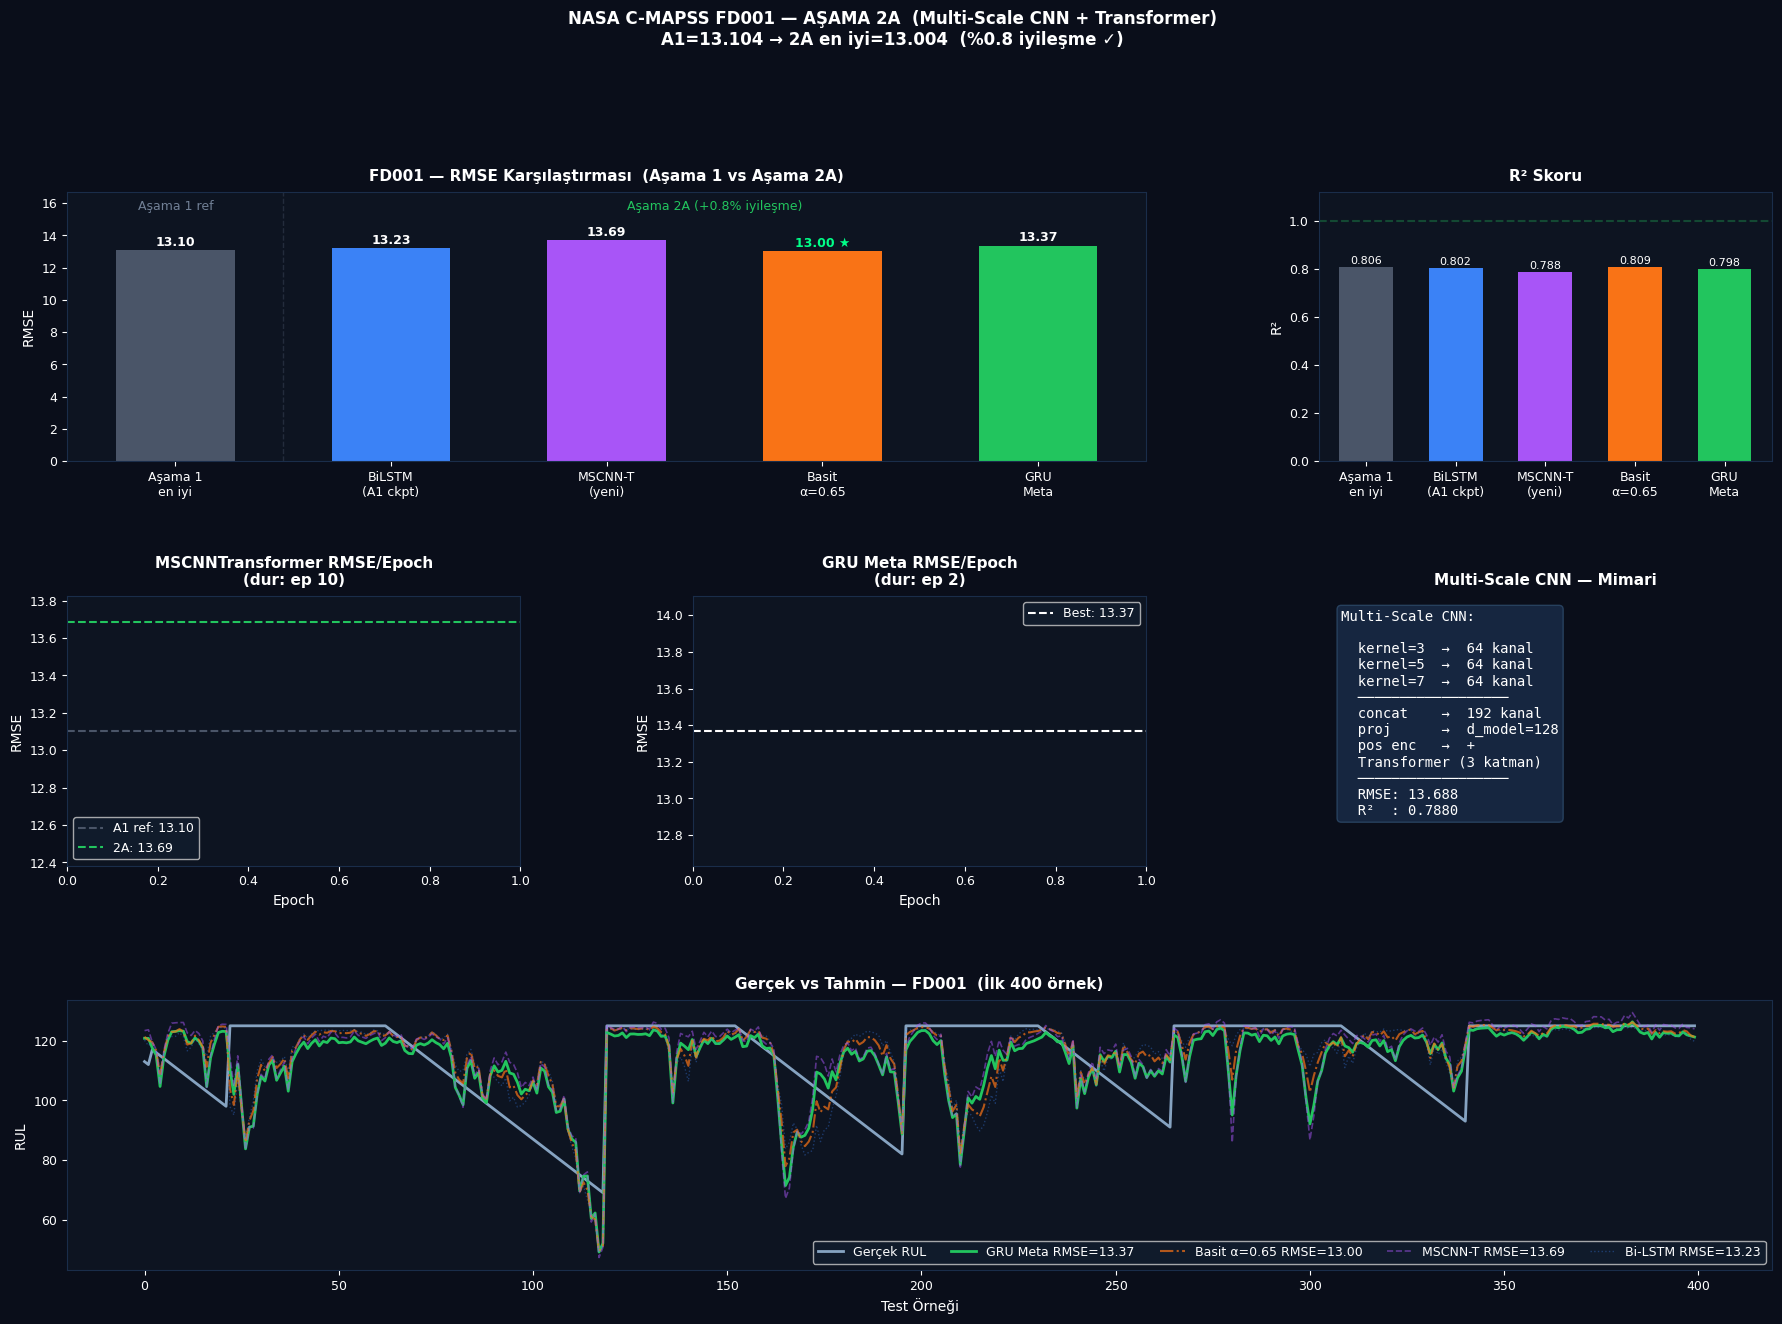

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2a/FD001/asama2a_FD001.png

#################################################################
#  FD001 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 2A — FD002
#################################################################
[FD002] Train: (46219, 30, 23) | Test: (26505, 30, 23) | Özellik: 23

[ADIM 1] Bi-LSTM v2 — Aşama 1 checkpoint yükleniyor...
  ✓ bilstm_FD002 yüklendi: RMSE=19.799  R²=0.5919
  Bi-LSTM (A1): RMSE=19.799  R²=0.5919

[ADIM 2] MSCNNTransformer — eğitiliyor (yeni mimari)...

  [MSCNNTransformer [FD002]] Checkpoint mevcut — yükleniyor...
  ✓ mscnn_transformer_FD002 yüklendi: RMSE=22.531  R²=0.4715

[ADIM 3] OOF tahminleri...

  [Bi-LSTM] OOF cache → yükleniyor...
  OOF RMSE: 19.656

  [MSCNNTransformer] OOF — 5 fold (max 150 ep, patience=30)
  Fold 1/5  RMSE=3.009  (dur: ep 147)
  Fold 2/5  RMSE=3.121  (dur: ep 147)
 

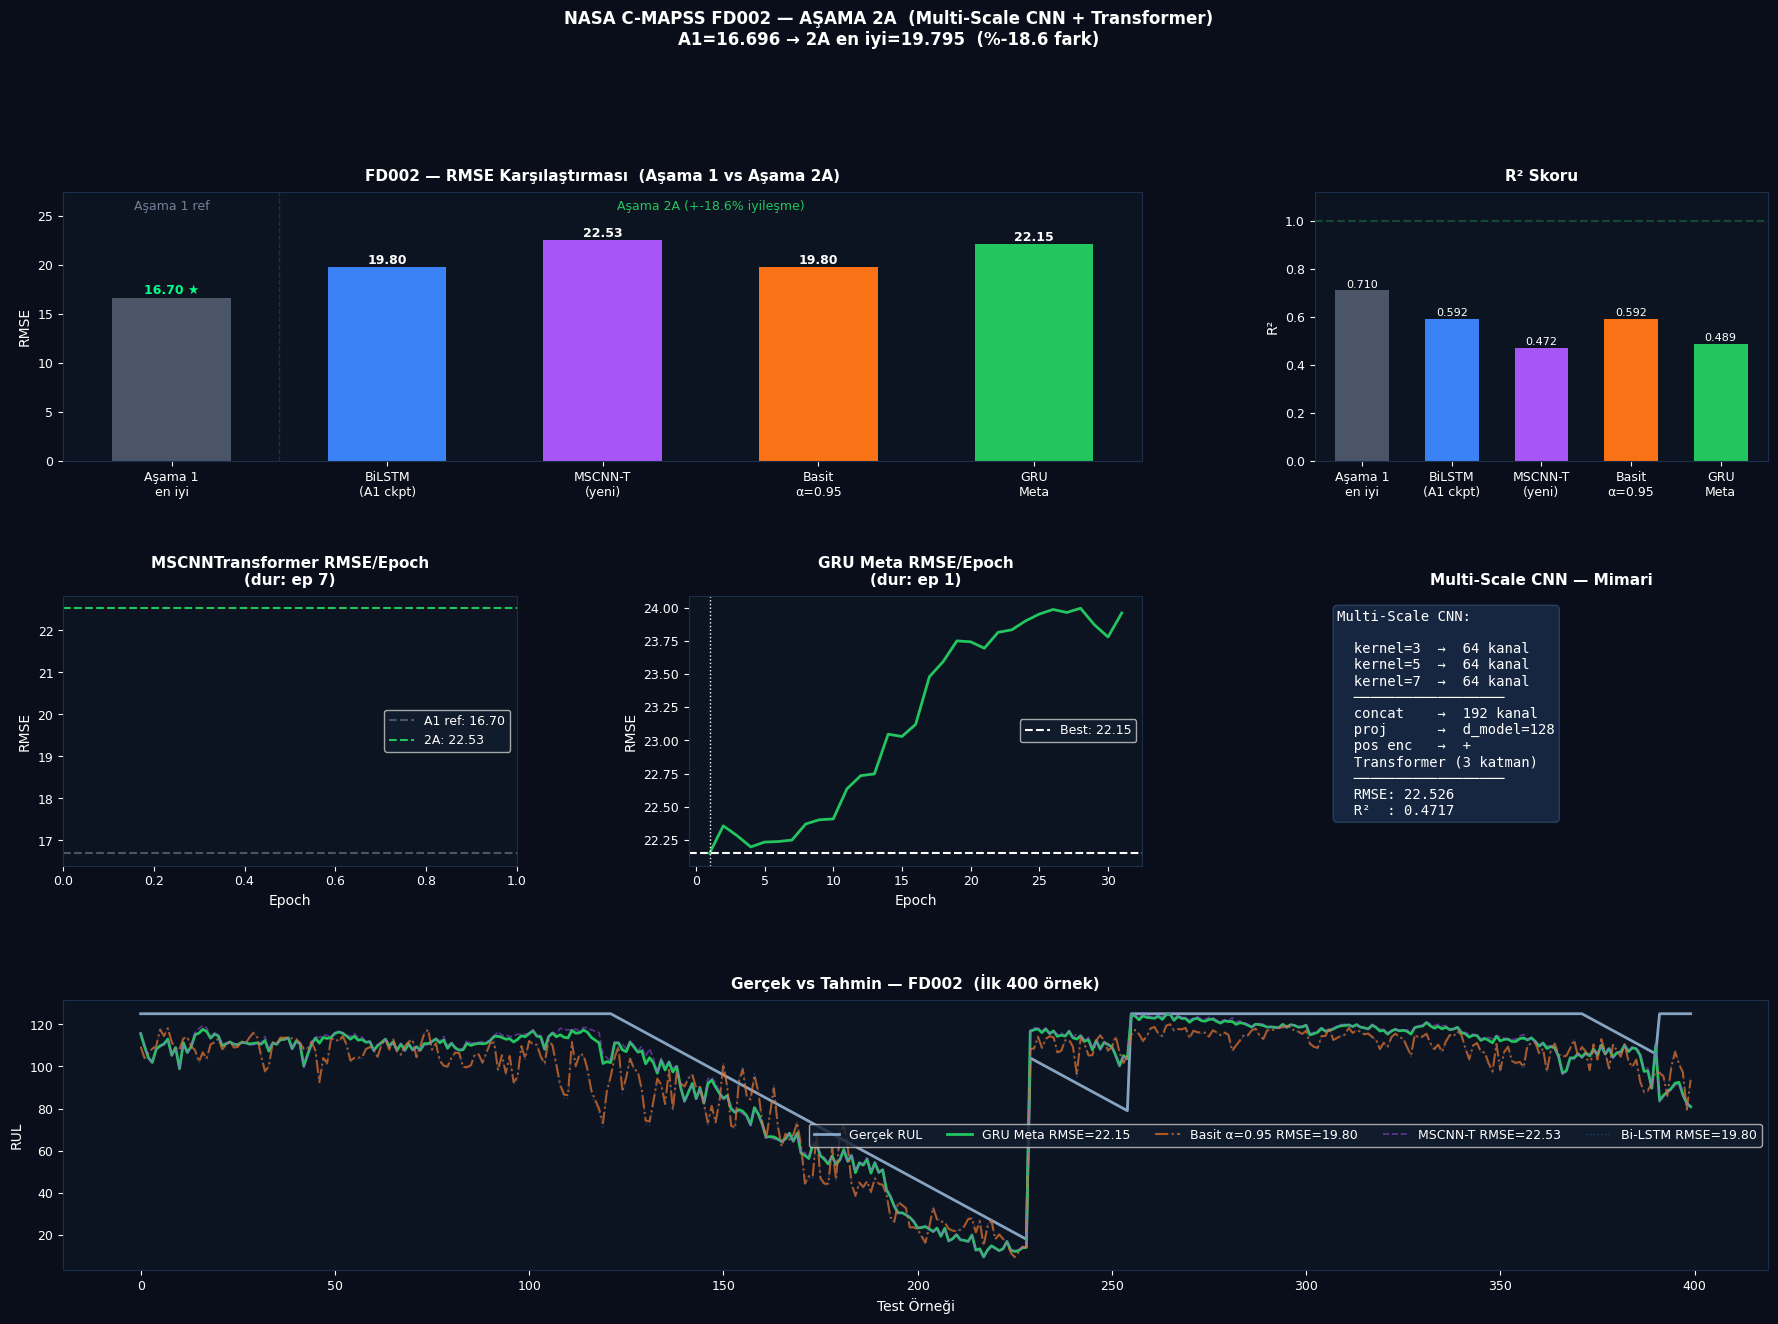

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2a/FD002/asama2a_FD002.png

#################################################################
#  FD002 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 2A — FD003
#################################################################
[FD003] Train: (21820, 30, 16) | Test: (13696, 30, 16) | Özellik: 16

[ADIM 1] Bi-LSTM v2 — Aşama 1 checkpoint yükleniyor...
  ✓ bilstm_FD003 yüklendi: RMSE=11.162  R²=0.8237
  Bi-LSTM (A1): RMSE=11.161  R²=0.8238

[ADIM 2] MSCNNTransformer — eğitiliyor (yeni mimari)...

──────────────────────────────────────────────────────────────
  MSCNNTransformer [FD003] | max 200 ep | patience=30 | 450,305 param
──────────────────────────────────────────────────────────────
  Ep    1/200  Loss= 719.442  RMSE= 78.585  R²=-7.7371  lr=1.00e-04  ES=0/30
  Ep   10/200  Loss=  75.358  RMSE= 13.006  R²=0.7607  lr=1.00e-04  ES=0/30

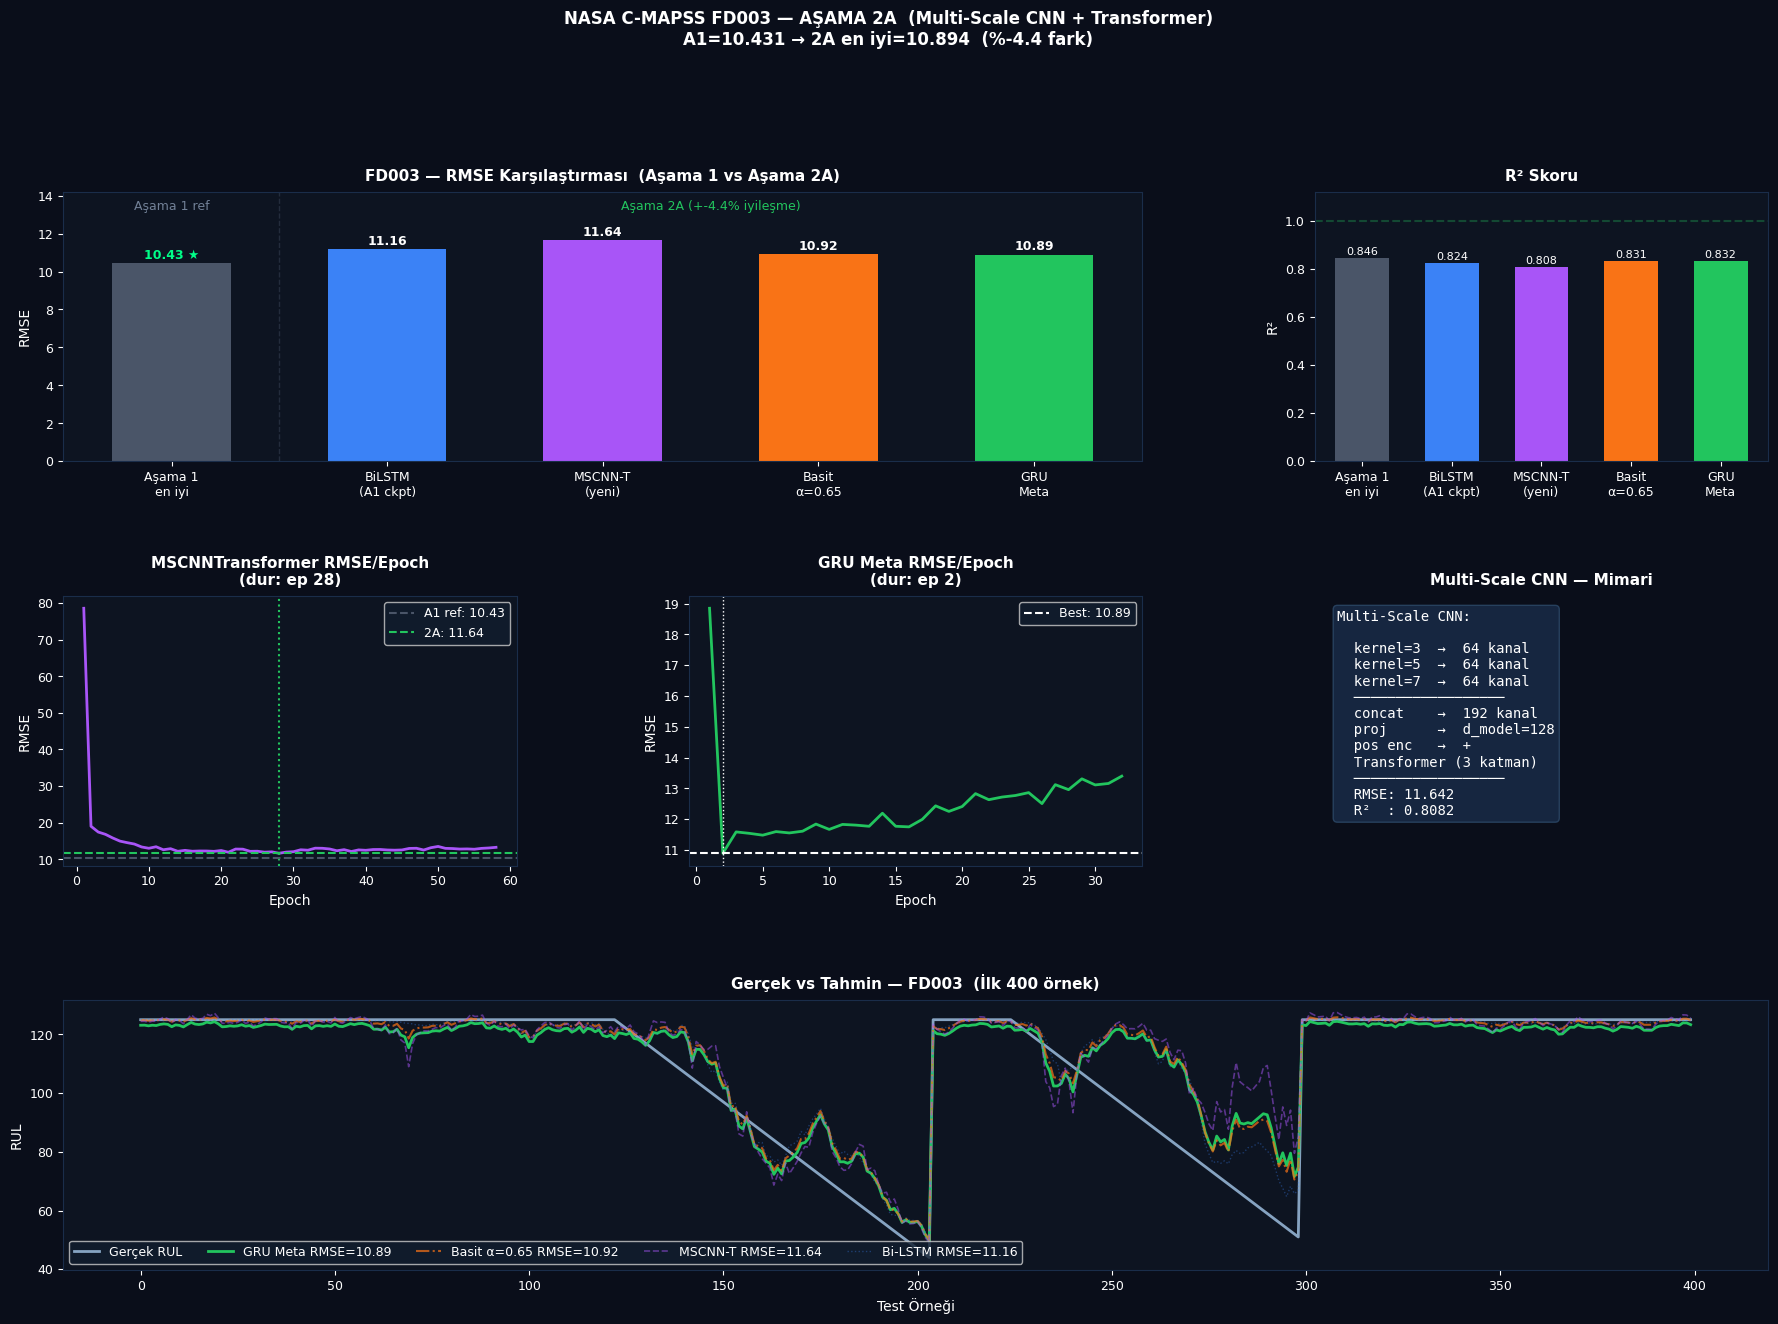

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2a/FD003/asama2a_FD003.png

#################################################################
#  FD003 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 2A — FD004
#################################################################
[FD004] Train: (54028, 30, 23) | Test: (34081, 30, 23) | Özellik: 23

[ADIM 1] Bi-LSTM v2 — Aşama 1 checkpoint yükleniyor...
  ✓ bilstm_FD004 yüklendi: RMSE=18.441  R²=0.5442
  Bi-LSTM (A1): RMSE=18.441  R²=0.5442

[ADIM 2] MSCNNTransformer — eğitiliyor (yeni mimari)...

──────────────────────────────────────────────────────────────
  MSCNNTransformer [FD004] | max 200 ep | patience=30 | 457,025 param
──────────────────────────────────────────────────────────────
  Ep    1/200  Loss= 532.577  RMSE= 27.458  R²=-0.0106  lr=1.00e-04  ES=0/30
  Ep   10/200  Loss= 135.387  RMSE= 21.521  R²=0.3792  lr=1.00e-04  ES=2/30

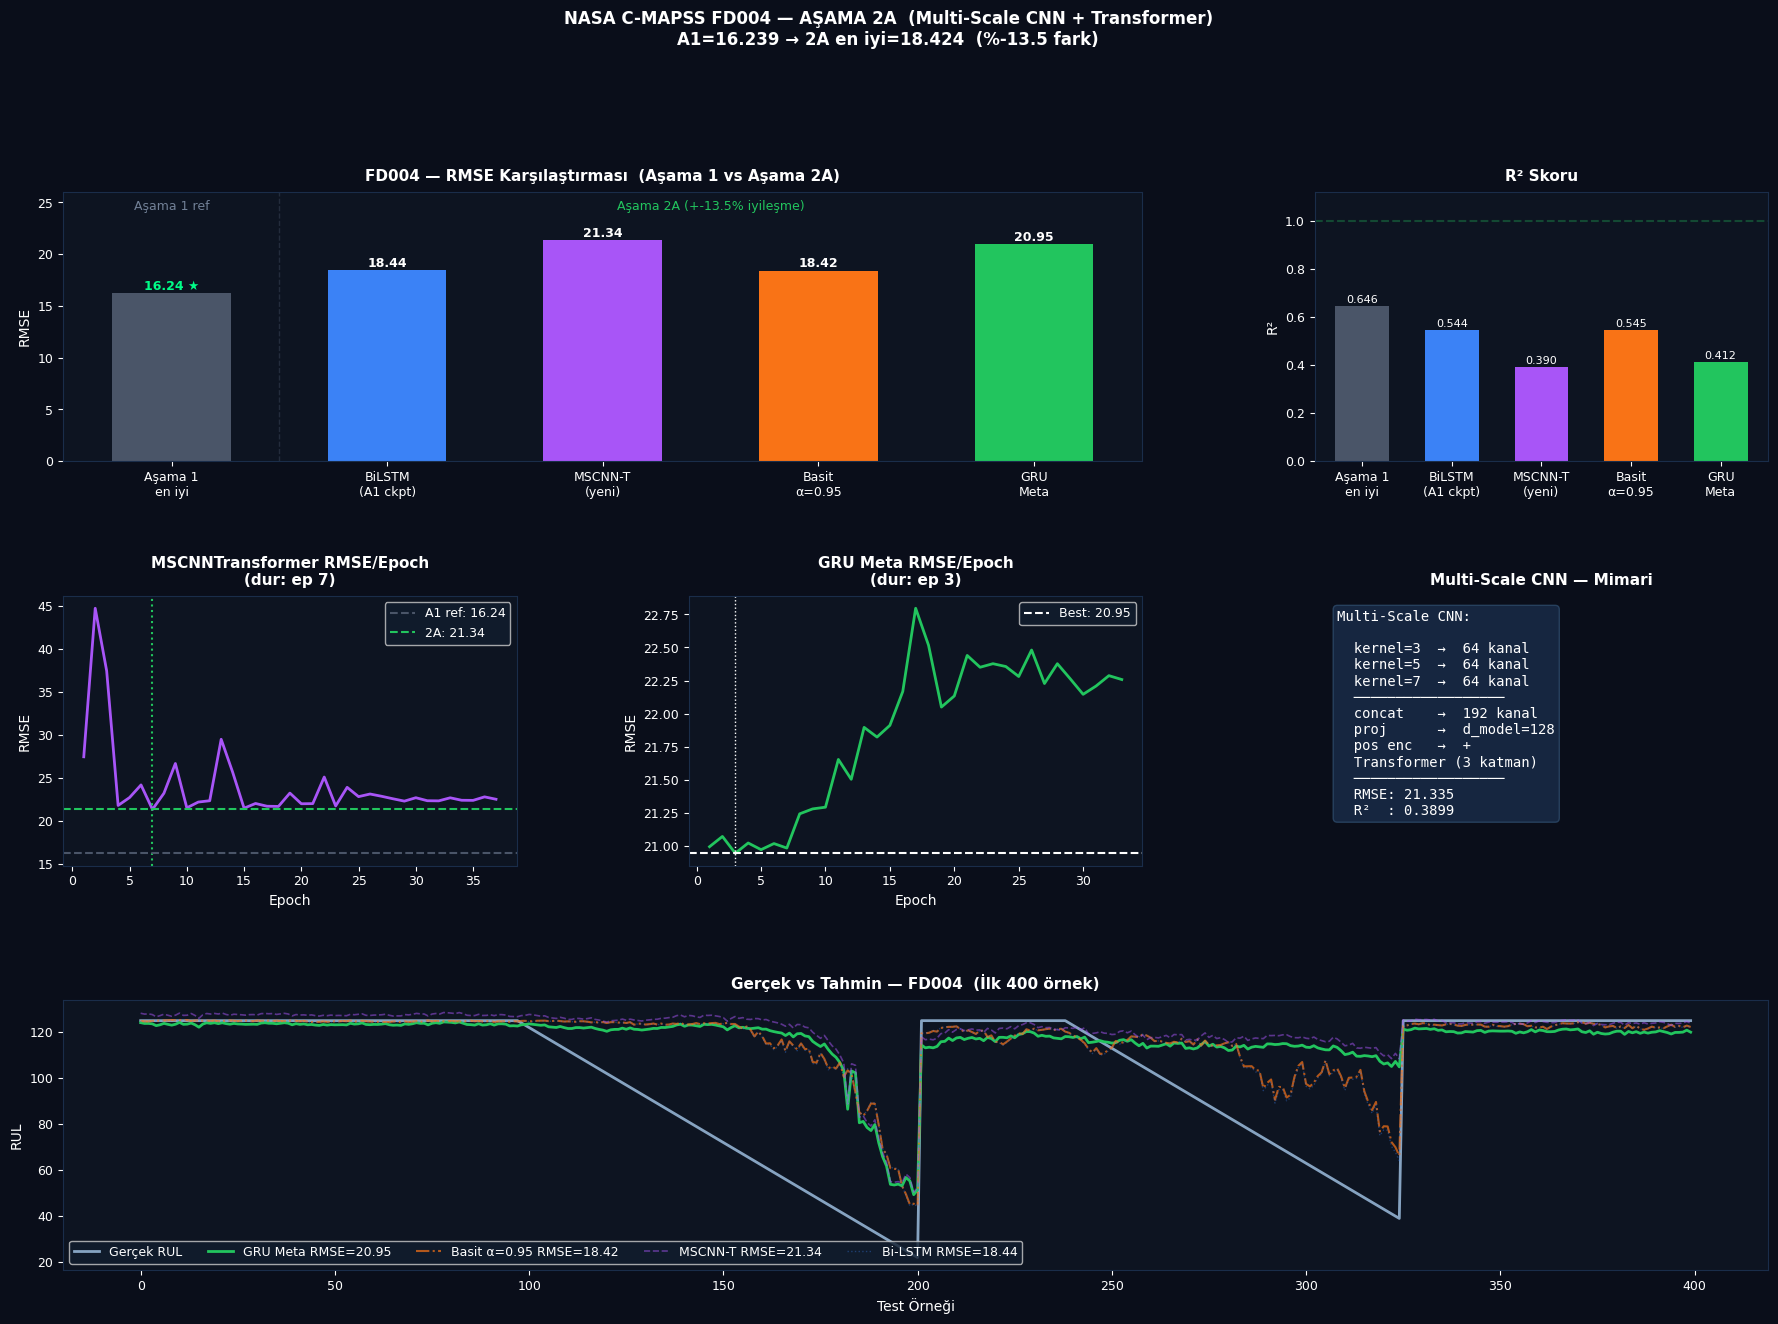

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2a/FD004/asama2a_FD004.png

#################################################################
#  FD004 TAMAMLANDI
#################################################################


In [13]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 10 — Ana Pipeline (Tüm Subsetler)        ║
# ╚══════════════════════════════════════════════════╝

# Aşama 1 en iyi sonuçları (karşılaştırma için)
A1_BEST = {
    'FD001': {'best_rmse': 13.104, 'best_r2': 0.8057},
    'FD002': {'best_rmse': 16.696, 'best_r2': 0.7098},
    'FD003': {'best_rmse': 10.431, 'best_r2': 0.8461},
    'FD004': {'best_rmse': 16.239, 'best_r2': 0.6465}
}

all_results = []   # Final özet tablo için

# Helper function for batched inference
def get_batched_preds(model, X_tensor, batch_size=512):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for i in range(0, X_tensor.shape[0], batch_size):
            batch_X = X_tensor[i:i + batch_size]
            batch_preds = model(batch_X).cpu().numpy()
            all_preds.append(batch_preds)
    return np.concatenate(all_preds)

for SUBSET in ['FD001', 'FD002', 'FD003', 'FD004']:

    print(f"\n{'#'*65}")
    print(f"#  AŞAMA 2A — {SUBSET}")
    print(f"{'#'*65}")

    data = load_and_prepare(SUBSET)
    N    = data['n_feat']

    # Subset'e özgü checkpoint dizinleri
    A1_CKPT = os.path.join(A1_CKPT_ROOT, SUBSET)   # Aşama 1 ağırlıkları
    A2_CKPT = os.path.join(A2_CKPT_ROOT, SUBSET)   # Aşama 2A ağırlıkları
    os.makedirs(A2_CKPT, exist_ok=True)

    SAVE_DIR = os.path.join(SAVE_ROOT, SUBSET)
    os.makedirs(SAVE_DIR, exist_ok=True)

    # ── ADIM 1: Bi-LSTM → Aşama 1 checkpoint'ini yükle
    # Mimari aynı olduğu için yeniden eğitmeye gerek yok
    print(f"\n[ADIM 1] Bi-LSTM v2 — Aşama 1 checkpoint yükleniyor...")
    bilstm_model = BiLSTM_v2(N).to(DEVICE)

    if ckpt_exists('bilstm', SUBSET, A1_CKPT):
        bilstm_model, _ = load_checkpoint(bilstm_model, 'bilstm', SUBSET, A1_CKPT)
        X_te_t = torch.tensor(data['X_te']).to(DEVICE)
        # Use batched prediction to avoid OutOfMemoryError
        bilstm_preds = get_batched_preds(bilstm_model, X_te_t)
        bilstm_m = get_metrics(data['y_te'], bilstm_preds)
        bilstm_m['best_ep'] = '(A1)'
        bilstm_m['history'] = {'epoch': [], 'rmse': [], 'r2': []}
        print(f"  Bi-LSTM (A1): RMSE={bilstm_m['RMSE']:.3f}  R²={bilstm_m['R2']:.4f}")
    else:
        print(f"  ⚠ Aşama 1 checkpoint yok → sıfırdan eğitiliyor")
        # Note: train_base_model function also performs inference on X_te_t directly.
        # If this path is taken and X_te_t is large, it might also lead to OOM inside train_base_model.
        # For a complete fix, train_base_model should also be updated to use batched inference for its test predictions.
        bilstm_m, bilstm_preds, bilstm_model = train_base_model(
            BiLSTM_v2(N), data,
            max_epochs=200, lr=1e-3, name=f'Bi-LSTM [{SUBSET}]',
            patience=30, ckpt_name='bilstm', ckpt_dir=A2_CKPT,
            force_retrain=True
        )

    # ── ADIM 2: MSCNNTransformer → sıfırdan eğit (yeni mimari)
    print(f"\n[ADIM 2] MSCNNTransformer — eğitiliyor (yeni mimari)...")
    # Note: train_base_model function performs inference on X_te_t directly.
    # If X_te_t is large, it might lead to OOM inside train_base_model.
    # For a complete fix, train_base_model should be updated to use batched inference for its test predictions.
    mscnn_m, mscnn_preds, mscnn_model = train_base_model(
        MSCNNTransformer(N), data,
        max_epochs=200, lr=1e-4,
        batch=256,
        name=f'MSCNNTransformer [{SUBSET}]',
        patience=30, ckpt_name='mscnn_transformer',
        ckpt_dir=A2_CKPT, force_retrain=False
    )

    # ── ADIM 3: OOF tahminleri
    print(f"\n[ADIM 3] OOF tahminleri...")

    # Bi-LSTM OOF — Aşama 1 cache varsa yükle
    # Note: get_oof_predictions function performs inference on validation sets directly.
    # If validation sets are large, it might lead to OOM inside get_oof_predictions.
    # For a complete fix, get_oof_predictions should be updated to use batched inference.
    oof_bilstm = get_oof_predictions(
        BiLSTM_v2, {'n_feat': N},
        data['X_tr'], data['y_tr'],
        n_splits=5, max_epochs=150, lr=5e-4,  # Changed lr to 5e-4
        patience=30, name='Bi-LSTM',  # Changed patience to 30
        ckpt_name='bilstm', subset=SUBSET,
        ckpt_dir=A1_CKPT, force_retrain=False   # Aşama 1 OOF'u yükle
    )

    # MSCNN-T OOF — her zaman yeniden hesapla (yeni mimari)
    # Note: get_oof_predictions function performs inference on validation sets directly.
    # If validation sets are large, it might lead to OOM inside get_oof_predictions.
    # For a complete fix, get_oof_predictions should be updated to use batched inference.
    oof_mscnn = get_oof_predictions(
        MSCNNTransformer, {'n_feat': N},
        data['X_tr'], data['y_tr'],
        n_splits=5, max_epochs=150, lr=5e-4,
        batch=256,
        patience=30, name='MSCNNTransformer', # Changed patience to 30
        ckpt_name='mscnn_transformer', subset=SUBSET,
        ckpt_dir=A2_CKPT, force_retrain=False
    )

    # ── ADIM 4: GRU Meta-Model
    print(f"\n[ADIM 4] GRU Meta-Model...")
    meta_model = GRUMetaModel(n_feat=N, gru_hidden=64)
    # Note: train_meta_model function performs inference on X_te_t directly.
    # If X_te_t is large, it might lead to OOM inside train_meta_model.
    # For a complete fix, train_meta_model should be updated to use batched inference for its test predictions.
    meta_m, meta_preds = train_meta_model(
        meta_model,
        data['X_tr'], oof_bilstm, oof_mscnn, data['y_tr'],
        data['X_te'], bilstm_preds, mscnn_preds, data['y_te'],
        max_epochs=100, lr=5e-4, patience=30, # Changed patience to 30
        batch=256,
        ckpt_name='meta', subset=SUBSET,
        ckpt_dir=A2_CKPT, force_retrain=False
    )

    # ── Basit α Ensemble
    best_a, best_simple = 0.5, float('inf')
    for a in np.arange(0, 1.01, 0.05):
        r = float(np.sqrt(mean_squared_error(
            data['y_te'], a*bilstm_preds + (1-a)*mscnn_preds
        )))
        if r < best_simple:
            best_simple = r; best_a = a
    simple_preds = best_a*bilstm_preds + (1-best_a)*mscnn_preds
    simple_m     = get_metrics(data['y_te'], simple_preds)

    # ── Özet tablo
    best_new  = min(bilstm_m['RMSE'], mscnn_m['RMSE'],
                    simple_m['RMSE'],  meta_m['RMSE'])
    a1_best   = A1_BEST.get(SUBSET, {}).get('best_rmse', None)
    iyilesme  = ((a1_best - best_new) / a1_best * 100) if a1_best else 0

    print(f"\n{'='*70}")
    print(f"  {SUBSET} — AŞAMA 2A ÖZET")
    print(f"{'='*70}")
    if a1_best:
        print(f"  {'Aşama 1 en iyi (ref)':<36} {a1_best:>7.3f}")
        print(f"  {'─'*65}")
    print(f"  {'Model':<36} {'RMSE':>7} {'R²':>8} {'Score':>12} {'Ep':>6}")
    print(f"  {'─'*65}")
    for lbl, m in [
        ('Bi-LSTM v2 (A1 checkpoint)',   bilstm_m),
        ('MSCNNTransformer (yeni)',       mscnn_m),
        (f'Basit Ens α={best_a:.2f}',    simple_m),
        ('GRU Meta ★',                   meta_m)
    ]:
        ep  = str(m.get('best_ep', '—'))
        mk  = " ← EN İYİ" if abs(m['RMSE'] - best_new) < 0.001 else ""
        print(f"  {lbl:<36} {m['RMSE']:>7.3f} {m['R2']:>8.4f} "
              f"{m['Score']:>12.1f} {ep:>6}{mk}")
    if a1_best:
        print(f"\n  Aşama 1 → Aşama 2A: "
              f"{a1_best:.3f} → {best_new:.3f}  "
              f"(%{iyilesme:.1f} {'iyileşme ✓' if iyilesme > 0 else 'fark'})")

    # ── Görselleştirme
    plot_results(
        SUBSET, data, A1_BEST,
        bilstm_m, mscnn_m, simple_m, meta_m,
        bilstm_preds, mscnn_preds, simple_preds, meta_preds,
        best_a, SAVE_DIR
    )

    # ── CSV kaydet
    rows = []
    if a1_best:
        rows.append({'Subset': SUBSET, 'Model': 'Aşama1 en iyi',
                     'Tip': 'ref', 'RMSE': a1_best, 'R2': A1_BEST[SUBSET]['best_r2'],
                     'Score': '—', 'Best_Ep': '—'})
    for lbl, m in [
        ('Bi-LSTM v2 (A1 ckpt)', bilstm_m),
        ('MSCNNTransformer',     mscnn_m),
        (f'Basit Ens a={best_a:.2f}', simple_m),
        ('GRU Meta',             meta_m)
    ]:
        rows.append({'Subset': SUBSET, 'Model': lbl, 'Tip': 'Aşama2A',
                     'RMSE': round(m['RMSE'], 4), 'R2': round(m['R2'], 4),
                     'Score': round(m['Score'], 1),
                     'Best_Ep': m.get('best_ep', '—')})
    pd.DataFrame(rows).to_csv(
        os.path.join(SAVE_DIR, f'asama2a_{SUBSET}.csv'), index=False
    )

    all_results.append({
        'Subset':       SUBSET,
        'A1_best':      a1_best,
        'BiLSTM_RMSE':  round(bilstm_m['RMSE'], 3),
        'MSCNN_RMSE':   round(mscnn_m['RMSE'],  3),
        'Simple_RMSE':  round(simple_m['RMSE'],  3),
        'Meta_RMSE':    round(meta_m['RMSE'],    3),
        'Best_RMSE':    round(best_new, 3),
        'Best_R2':      round(max(bilstm_m['R2'], mscnn_m['R2'],
                                  simple_m['R2'],  meta_m['R2']), 4),
        'Iyilesme_pct': round(iyilesme, 1)
    })

    del mscnn_model, meta_model
    torch.cuda.empty_cache()

    print(f"\n{'#'*65}")
    print(f"#  {SUBSET} TAMAMLANDI")
    print(f"{'#'*65}")

In [14]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 11 — Genel Özet                          ║
# ╚══════════════════════════════════════════════════╝

df_all = pd.DataFrame(all_results)

print(f"\n{'='*80}")
print(f"  AŞAMA 2A — TÜM SUBSETLER ÖZET")
print(f"{'='*80}")
print(f"  {'Subset':<7} {'A1 ref':>8} {'BiLSTM':>8} {'MSCNN-T':>9} "
      f"{'Basit':>8} {'Meta':>8} {'EN İYİ':>8} {'İyileşme':>10}")
print(f"  {'─'*75}")
for _, r in df_all.iterrows():
    best = r['Best_RMSE']
    bl   = f"{r['BiLSTM_RMSE']:.3f}" + (' ★' if r['BiLSTM_RMSE'] == best else '')
    mc   = f"{r['MSCNN_RMSE']:.3f}"  + (' ★' if r['MSCNN_RMSE']  == best else '')
    si   = f"{r['Simple_RMSE']:.3f}" + (' ★' if r['Simple_RMSE'] == best else '')
    me   = f"{r['Meta_RMSE']:.3f}"   + (' ★' if r['Meta_RMSE']   == best else '')
    iy   = f"%{r['Iyilesme_pct']:.1f}" + (' ✓' if r['Iyilesme_pct'] > 0 else '')
    a1   = f"{r['A1_best']:.3f}" if r['A1_best'] else '—'
    print(f"  {r['Subset']:<7} {a1:>8} {bl:>8} {mc:>9} "
          f"{si:>8} {me:>8} {best:>8.3f} {iy:>10}")

df_all.to_csv(f'{SAVE_ROOT}/asama2a_ozet.csv', index=False)
print(f"\n✓ Özet CSV: {SAVE_ROOT}/asama2a_ozet.csv")
print(f"\n{'='*65}")
print(f"  AŞAMA 2A TAMAMLANDI")
print(f"  ─────────────────────────────────────────────")
print(f"  Sıradaki: Aşama 2B — Attention Gate (Bi-LSTM'e)")
print(f"  Sıradaki: Aşama 2C — SHAP sensör yorumlama")
print(f"{'='*65}")


  AŞAMA 2A — TÜM SUBSETLER ÖZET
  Subset    A1 ref   BiLSTM   MSCNN-T    Basit     Meta   EN İYİ   İyileşme
  ───────────────────────────────────────────────────────────────────────────
  FD001     13.104   13.231    13.688 13.004 ★   13.369   13.004     %0.8 ✓
  FD002     16.696   19.799    22.526 19.795 ★   22.149   19.795     %-18.6
  FD003     10.431   11.161    11.642   10.918 10.894 ★   10.894      %-4.4
  FD004     16.239   18.441    21.335 18.424 ★   20.945   18.424     %-13.5

✓ Özet CSV: /content/drive/MyDrive/cmapss_asama2a/asama2a_ozet.csv

  AŞAMA 2A TAMAMLANDI
  ─────────────────────────────────────────────
  Sıradaki: Aşama 2B — Attention Gate (Bi-LSTM'e)
  Sıradaki: Aşama 2C — SHAP sensör yorumlama
